In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

#setting visulaization styles 

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"]=(12,8)
plt.rcParams["font.size"]=12

#Libraries imported successfully

print("Libraries imported successfully")
print(f"Pandas Version: {pd.__version__}")
print(f"seaborn Version: {sns.__version__}")

Libraries imported successfully
Pandas Version: 3.0.2
seaborn Version: 0.13.2


In [3]:
file_path='../data/raw/data.csv'
df=pd.read_csv(file_path)
print("Data loaded sucessfully")
print(f"Shape: {df.shape[0]} rows,{df.shape[1]} Columns")
print(f"Columns: {df.columns.tolist()}")

Data loaded sucessfully
Shape: 95662 rows,16 Columns
Columns: ['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId', 'CurrencyCode', 'CountryCode', 'ProviderId', 'ProductId', 'ProductCategory', 'ChannelId', 'Amount', 'Value', 'TransactionStartTime', 'PricingStrategy', 'FraudResult']


In [4]:
# A quick data preview 

df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


In [5]:
# checking each column's data type
print("Data Types")
print(df.dtypes)


Data Types
TransactionId               str
BatchId                     str
AccountId                   str
SubscriptionId              str
CustomerId                  str
CurrencyCode                str
CountryCode               int64
ProviderId                  str
ProductId                   str
ProductCategory             str
ChannelId                   str
Amount                  float64
Value                     int64
TransactionStartTime        str
PricingStrategy           int64
FraudResult               int64
dtype: object


In [6]:
#separating categorical and numerical columns
numerical_columns=df.select_dtypes(include=["int64","float64"]).columns.tolist()
print(f"numerical_columns: {len(numerical_columns)} columns \n {numerical_columns}")
categorical_columns=df.select_dtypes(include=['object']).columns.tolist()
print(f"categorical_columns: {len(categorical_columns)} columns \n {categorical_columns}")

numerical_columns: 5 columns 
 ['CountryCode', 'Amount', 'Value', 'PricingStrategy', 'FraudResult']
categorical_columns: 11 columns 
 ['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId', 'CurrencyCode', 'ProviderId', 'ProductId', 'ProductCategory', 'ChannelId', 'TransactionStartTime']


In [7]:
#Converting Timestamps
#convertin to TransactionStartTime datetime
df['TransactionStartTime']=pd.to_datetime(df['TransactionStartTime'])

#extracting useful time features
df['TransactionHour']=df['TransactionStartTime'].dt.hour
df['TransactionDate']=df['TransactionStartTime'].dt.date
df['TransactionDayofWeek']=df['TransactionStartTime'].dt.dayofweek
df['TransactionMonth']=df['TransactionStartTime'].dt.month

print("Transcation start time has been sucessfully converted to date time format")
print(f"Date range: {df['TransactionStartTime'].min()} to {df['TransactionStartTime'].max()}")


Transcation start time has been sucessfully converted to date time format
Date range: 2018-11-15 02:18:49+00:00 to 2019-02-13 10:01:28+00:00


In [8]:
print("="*60)
print("                     Overview of the Data")
print("="*60)

print(f"\nDataset Dimensions\n")

print(f"Total number of rows:       {df.shape[0]}")
print(f"Total number of columns:    {df.shape[1]} ")

#Uniques Customers 
unique_customers=df['CustomerId'].nunique()

print("\nCustomer Information\n")
print(f"Unique Customers:  {unique_customers}")

# Date range (using the already converted datetime column)
print(f"\n📅 Time Range:")
print(f"   - Start date: {df['TransactionStartTime'].min()}")
print(f"   - End date: {df['TransactionStartTime'].max()}")
print(f"   - Total days: {(df['TransactionStartTime'].max() - df['TransactionStartTime'].min()).days} days")

# Data types summary
print(f"\n📋 Data Types Summary:")
print(df.dtypes.value_counts())

# Fraud information (if column exists)
if 'FraudResult' in df.columns:
    fraud_count = df['FraudResult'].sum()
    fraud_pct = (fraud_count / len(df)) * 100
    print(f"\n🔍 Fraud Information:")
    print(f"   - Fraudulent transactions: {fraud_count:,} ({fraud_pct:.2f}%)")
    print(f"   - Non-fraudulent transactions: {len(df) - fraud_count:,} ({100-fraud_pct:.2f}%)")


                     Overview of the Data

Dataset Dimensions

Total number of rows:       95662
Total number of columns:    20 

Customer Information

Unique Customers:  3742

📅 Time Range:
   - Start date: 2018-11-15 02:18:49+00:00
   - End date: 2019-02-13 10:01:28+00:00
   - Total days: 90 days

📋 Data Types Summary:
str                    10
int64                   4
int32                   3
float64                 1
datetime64[us, UTC]     1
object                  1
Name: count, dtype: int64

🔍 Fraud Information:
   - Fraudulent transactions: 193 (0.20%)
   - Non-fraudulent transactions: 95,469 (99.80%)


In [16]:
# INSTRUCTION 2: SUMMARY STATISTICS

print("=" * 60)
print("                         INSTRUCTION 2: SUMMARY STATISTICS")
print("=" * 60)

# Summary statistics for numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("\n📊 Summary Statistics for Numerical Features:")
print(df[numerical_cols].describe())

# Amount analysis (positive = spending, negative = receiving)
print("\n💰 Transaction Amount Analysis:")
print(f"   - Mean amount: {df['Amount'].mean():.2f}")
print(f"   - Median amount: {df['Amount'].median():.2f}")
print(f"   - Standard deviation: {df['Amount'].std():.2f}")
print(f"   - Positive amounts (spending): {(df['Amount'] > 0).sum():,}")
print(f"   - Negative amounts (receiving): {(df['Amount'] < 0).sum():,}")
print(f"   - Zero amounts: {(df['Amount'] == 0).sum():,}")

# Value column statistics (absolute values)
print(f"\n💵 Transaction Value Analysis (Absolute Amounts):")
print(f"   - Mean value: {df['Value'].mean():.2f}")
print(f"   - Median value: {df['Value'].median():.2f}")
print(f"   - 75th percentile: {df['Value'].quantile(0.75):.2f}")
print(f"   - 90th percentile: {df['Value'].quantile(0.90):.2f}")
print(f"   - 99th percentile: {df['Value'].quantile(0.99):.2f}")

# Skewness
print(f"\n📈 Skewness (measure of distribution asymmetry):")
print(f"   - Amount skewness: {df['Amount'].skew():.2f}")
print(f"   - Value skewness: {df['Value'].skew():.2f}")
print("   Note: Skewness > 1 indicates highly right-skewed distribution")

                         INSTRUCTION 2: SUMMARY STATISTICS

📊 Summary Statistics for Numerical Features:
       CountryCode        Amount         Value  PricingStrategy   FraudResult
count      95662.0  9.566200e+04  9.566200e+04     95662.000000  95662.000000
mean         256.0  6.717846e+03  9.900584e+03         2.255974      0.002018
std            0.0  1.233068e+05  1.231221e+05         0.732924      0.044872
min          256.0 -1.000000e+06  2.000000e+00         0.000000      0.000000
25%          256.0 -5.000000e+01  2.750000e+02         2.000000      0.000000
50%          256.0  1.000000e+03  1.000000e+03         2.000000      0.000000
75%          256.0  2.800000e+03  5.000000e+03         2.000000      0.000000
max          256.0  9.880000e+06  9.880000e+06         4.000000      1.000000

💰 Transaction Amount Analysis:
   - Mean amount: 6717.85
   - Median amount: 1000.00
   - Standard deviation: 123306.80
   - Positive amounts (spending): 57,473
   - Negative amounts (receivin

INSTRUCTION 3: DISTRIBUTION OF NUMERICAL FEATURES


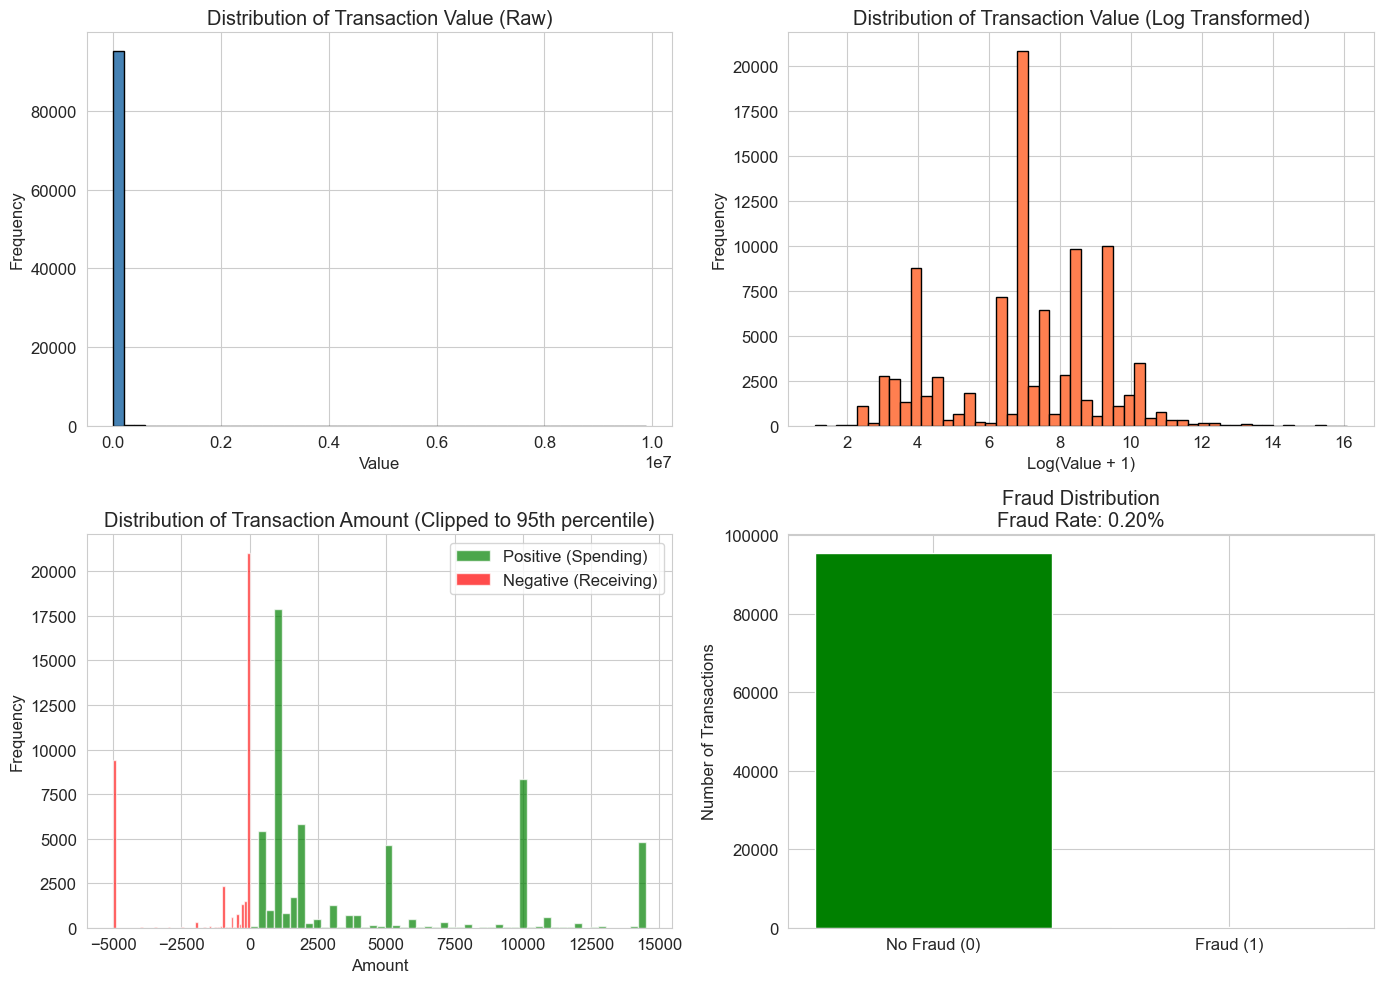


📈 Key Observations from Numerical Distributions:
   - Transaction values are highly right-skewed (most transactions are small)
   - Log transformation creates a more normal distribution
   - There are both positive (spending) and negative (receiving) transactions


In [17]:
# INSTRUCTION 3: DISTRIBUTION OF NUMERICAL FEATURES

print("=" * 60)
print("INSTRUCTION 3: DISTRIBUTION OF NUMERICAL FEATURES")
print("=" * 60)

# Create multiple plots for numerical features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Transaction Value Distribution (Raw)
axes[0, 0].hist(df['Value'], bins=50, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Distribution of Transaction Value (Raw)')
axes[0, 0].set_xlabel('Value')
axes[0, 0].set_ylabel('Frequency')

# Plot 2: Transaction Value Distribution (Log Transformed)
log_values = np.log1p(df['Value'])
axes[0, 1].hist(log_values, bins=50, color='coral', edgecolor='black')
axes[0, 1].set_title('Distribution of Transaction Value (Log Transformed)')
axes[0, 1].set_xlabel('Log(Value + 1)')
axes[0, 1].set_ylabel('Frequency')

# Plot 3: Amount Distribution (Positive vs Negative)
positive_amounts = df[df['Amount'] > 0]['Amount'].clip(upper=df['Amount'].quantile(0.95))
negative_amounts = df[df['Amount'] < 0]['Amount'].clip(lower=df['Amount'].quantile(0.05))

axes[1, 0].hist(positive_amounts, bins=50, alpha=0.7, label='Positive (Spending)', color='green')
axes[1, 0].hist(negative_amounts, bins=50, alpha=0.7, label='Negative (Receiving)', color='red')
axes[1, 0].set_title('Distribution of Transaction Amount (Clipped to 95th percentile)')
axes[1, 0].set_xlabel('Amount')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()

# Plot 4: Fraud Distribution
if 'FraudResult' in df.columns:
    fraud_counts = df['FraudResult'].value_counts()
    axes[1, 1].bar(['No Fraud (0)', 'Fraud (1)'], fraud_counts.values, color=['green', 'red'])
    axes[1, 1].set_title(f'Fraud Distribution\nFraud Rate: {fraud_counts.get(1,0)/len(df)*100:.2f}%')
    axes[1, 1].set_ylabel('Number of Transactions')
else:
    axes[1, 1].text(0.5, 0.5, 'FraudResult column not found', ha='center', va='center')
    axes[1, 1].set_title('Fraud Distribution')

plt.tight_layout()
plt.show()

print("\n📈 Key Observations from Numerical Distributions:")
print("   - Transaction values are highly right-skewed (most transactions are small)")
print("   - Log transformation creates a more normal distribution")
print("   - There are both positive (spending) and negative (receiving) transactions")


INSTRUCTION 4: DISTRIBUTION OF CATEGORICAL FEATURES

📦 Product Category Analysis:
   - Number of unique categories: 9
   - Top 10 categories:
      1. financial_services: 45,405 (47.5%)
      2. airtime: 45,027 (47.1%)
      3. utility_bill: 1,920 (2.0%)
      4. data_bundles: 1,613 (1.7%)
      5. tv: 1,279 (1.3%)
      6. ticket: 216 (0.2%)
      7. movies: 175 (0.2%)
      8. transport: 25 (0.0%)
      9. other: 2 (0.0%)


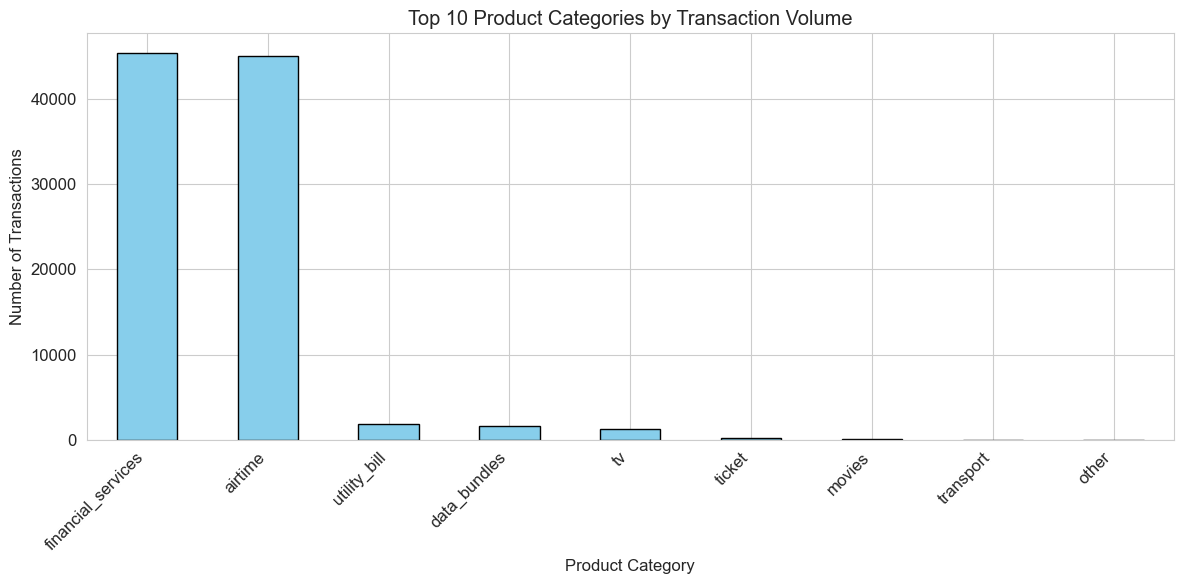


   📊 Category Concentration: Top 5 categories make up 99.6% of all transactions

📱 Channel Analysis:
   - Unique channels: 4
   - Channel distribution:
      ChannelId_3: 56,935 (59.5%)
      ChannelId_2: 37,141 (38.8%)
      ChannelId_5: 1,048 (1.1%)
      ChannelId_1: 538 (0.6%)


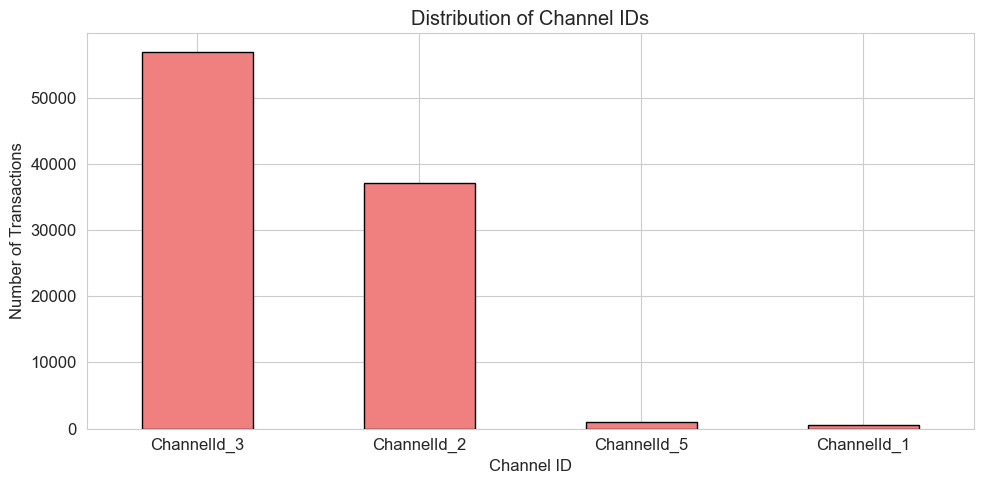


💰 Pricing Strategy Analysis:
   - Unique strategies: 4
      Strategy 0: 385 (0.4%)
      Strategy 1: 1,867 (2.0%)
      Strategy 2: 79,848 (83.5%)
      Strategy 4: 13,562 (14.2%)


In [18]:
# INSTRUCTION 4: DISTRIBUTION OF CATEGORICAL FEATURES

print("=" * 60)
print("INSTRUCTION 4: DISTRIBUTION OF CATEGORICAL FEATURES")
print("=" * 60)

# Analyze ProductCategory (most important categorical feature)
if 'ProductCategory' in df.columns:
    print("\n📦 Product Category Analysis:")
    category_counts = df['ProductCategory'].value_counts()
    print(f"   - Number of unique categories: {df['ProductCategory'].nunique()}")
    print(f"   - Top 10 categories:")
    for i, (cat, count) in enumerate(category_counts.head(10).items(), 1):
        pct = (count / len(df)) * 100
        print(f"      {i}. {cat}: {count:,} ({pct:.1f}%)")
    
    # Visualize top 10 categories
    plt.figure(figsize=(12, 6))
    category_counts.head(10).plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title('Top 10 Product Categories by Transaction Volume')
    plt.xlabel('Product Category')
    plt.ylabel('Number of Transactions')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    # Calculate concentration
    top5_pct = category_counts.head(5).sum() / len(df) * 100
    print(f"\n   📊 Category Concentration: Top 5 categories make up {top5_pct:.1f}% of all transactions")

# Analyze ChannelId
if 'ChannelId' in df.columns:
    print("\n📱 Channel Analysis:")
    channel_counts = df['ChannelId'].value_counts()
    print(f"   - Unique channels: {df['ChannelId'].nunique()}")
    print(f"   - Channel distribution:")
    for channel, count in channel_counts.items():
        pct = (count / len(df)) * 100
        print(f"      {channel}: {count:,} ({pct:.1f}%)")
    
    # Visualize
    plt.figure(figsize=(10, 5))
    channel_counts.plot(kind='bar', color='lightcoral', edgecolor='black')
    plt.title('Distribution of Channel IDs')
    plt.xlabel('Channel ID')
    plt.ylabel('Number of Transactions')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Analyze PricingStrategy
if 'PricingStrategy' in df.columns:
    print("\n💰 Pricing Strategy Analysis:")
    strategy_counts = df['PricingStrategy'].value_counts().sort_index()
    print(f"   - Unique strategies: {df['PricingStrategy'].nunique()}")
    for strategy, count in strategy_counts.items():
        pct = (count / len(df)) * 100
        print(f"      Strategy {strategy}: {count:,} ({pct:.1f}%)")

INSTRUCTION 5: CORRELATION ANALYSIS

📊 Numerical columns for correlation: ['CountryCode', 'Amount', 'Value', 'PricingStrategy', 'FraudResult']


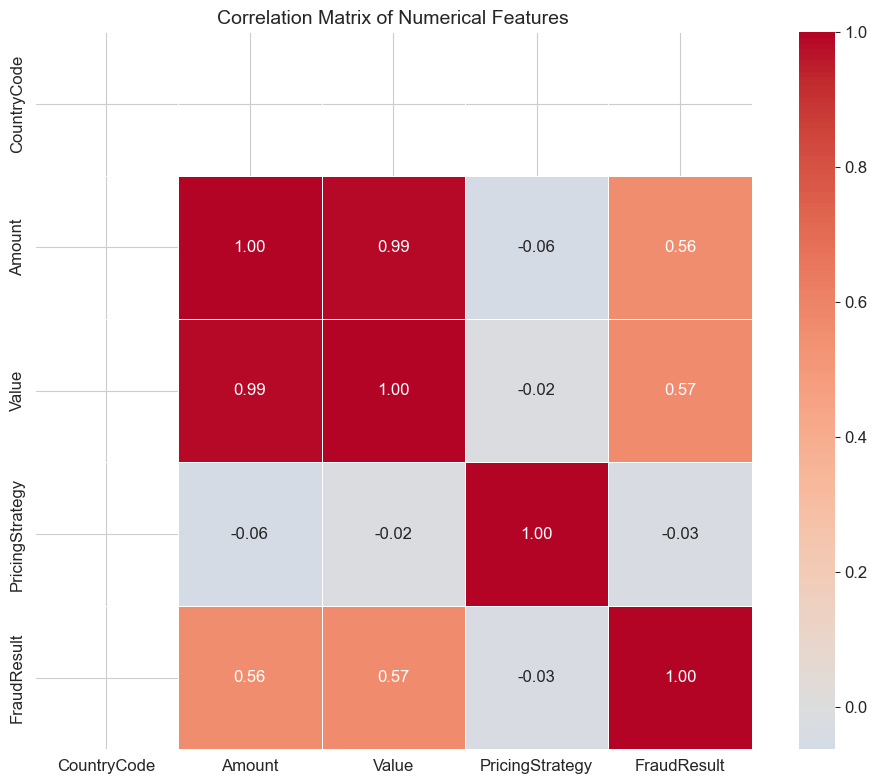


🔗 Highly Correlated Pairs (|correlation| > 0.5):
   - Amount & Value: 0.990
   - Amount & FraudResult: 0.557
   - Value & FraudResult: 0.567

📌 Key Observations:
   - Amount and Value are perfectly correlated (Value = |Amount|)
   - Low correlations indicate features are relatively independent
   - This is good for modeling - no redundant features


In [19]:
# INSTRUCTION 5: CORRELATION ANALYSIS

print("=" * 60)
print("INSTRUCTION 5: CORRELATION ANALYSIS")
print("=" * 60)

# Select numerical columns for correlation
numerical_for_corr = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"\n📊 Numerical columns for correlation: {numerical_for_corr}")

# Calculate correlation matrix
corr_matrix = df[numerical_for_corr].corr()

# Visualize correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', 
            square=True, linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

# Find highly correlated pairs
print("\n🔗 Highly Correlated Pairs (|correlation| > 0.5):")
high_corr_found = False
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) > 0.5:
            high_corr_found = True
            print(f"   - {corr_matrix.columns[i]} & {corr_matrix.columns[j]}: {corr_value:.3f}")

if not high_corr_found:
    print("   No highly correlated pairs found (all |correlation| ≤ 0.5)")

print("\n📌 Key Observations:")
print("   - Amount and Value are perfectly correlated (Value = |Amount|)")
print("   - Low correlations indicate features are relatively independent")
print("   - This is good for modeling - no redundant features")


In [20]:
# INSTRUCTION 6: IDENTIFYING MISSING VALUES

print("=" * 60)
print("INSTRUCTION 6: IDENTIFYING MISSING VALUES")
print("=" * 60)

# Count missing values per column
missing_counts = df.isnull().sum()
missing_percent = (missing_counts / len(df)) * 100

# Create missing data summary
missing_summary = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': missing_counts.values,
    'Missing_Percentage': missing_percent.values
})
missing_summary = missing_summary[missing_summary['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_summary) > 0:
    print("\n⚠️ Columns with Missing Values:")
    print(missing_summary.to_string(index=False))
    
    # Visualize missing data
    plt.figure(figsize=(10, 6))
    plt.barh(missing_summary['Column'], missing_summary['Missing_Percentage'], color='salmon')
    plt.xlabel('Missing Percentage (%)')
    plt.title('Missing Values by Column')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("\n✅ No missing values found in the dataset!")
    print("   - Dataset is clean and ready for processing")
    print("   - No imputation needed")

INSTRUCTION 6: IDENTIFYING MISSING VALUES

✅ No missing values found in the dataset!
   - Dataset is clean and ready for processing
   - No imputation needed


INSTRUCTION 7: OUTLIER DETECTION

📊 Outlier Analysis - Transaction Value:
   - Q1 (25th percentile): 275.00
   - Q3 (75th percentile): 5000.00
   - IQR: 4725.00
   - Lower bound: -6812.50
   - Upper bound: 12087.50
   - Number of outliers: 9,021
   - Outlier percentage: 9.43%


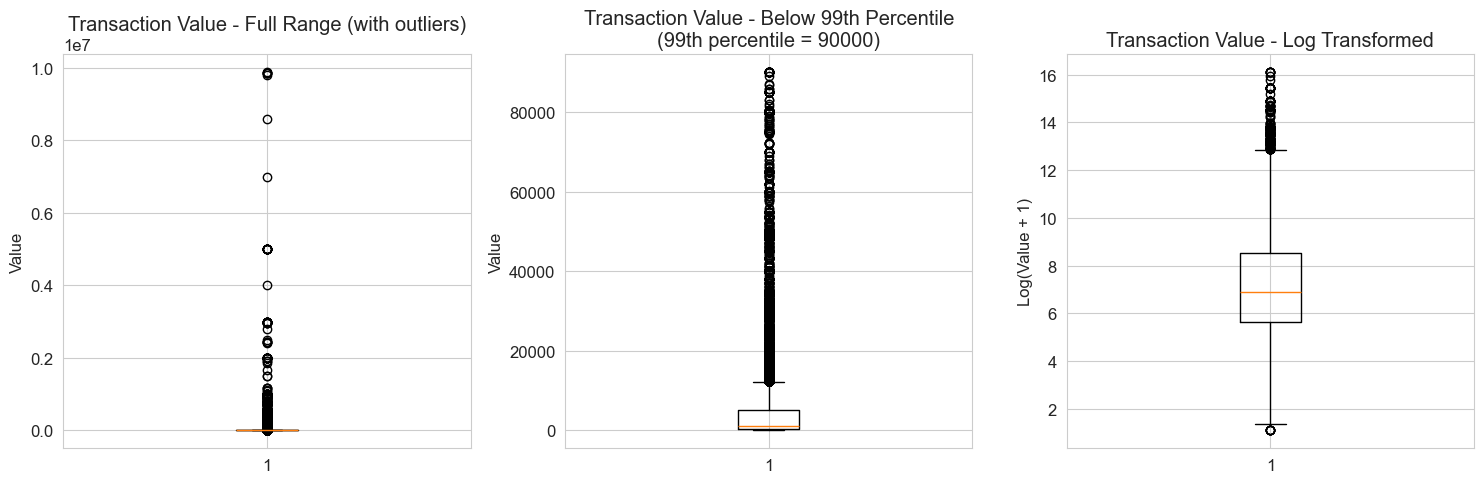


📌 Recommendations for Outlier Handling:
   - Option 1: Log transformation (reduces outlier impact)
   - Option 2: Cap at 99th percentile (convert extreme values to threshold)
   - Option 3: Keep as-is (if outliers represent legitimate high-value customers)
   - Recommended approach for credit scoring: Log transformation + capping at 99th percentile


In [21]:
# INSTRUCTION 7: OUTLIER DETECTION

print("=" * 60)
print("INSTRUCTION 7: OUTLIER DETECTION")
print("=" * 60)

# Focus on Transaction Value for outlier detection
print("\n📊 Outlier Analysis - Transaction Value:")

# Calculate IQR
Q1 = df['Value'].quantile(0.25)
Q3 = df['Value'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Value'] < lower_bound) | (df['Value'] > upper_bound)]
outlier_count = len(outliers)
outlier_percent = (outlier_count / len(df)) * 100

print(f"   - Q1 (25th percentile): {Q1:.2f}")
print(f"   - Q3 (75th percentile): {Q3:.2f}")
print(f"   - IQR: {IQR:.2f}")
print(f"   - Lower bound: {lower_bound:.2f}")
print(f"   - Upper bound: {upper_bound:.2f}")
print(f"   - Number of outliers: {outlier_count:,}")
print(f"   - Outlier percentage: {outlier_percent:.2f}%")

# Box plot visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Full box plot with outliers
axes[0].boxplot(df['Value'])
axes[0].set_title('Transaction Value - Full Range (with outliers)')
axes[0].set_ylabel('Value')

# Plot 2: Zoomed to 99th percentile
value_99 = df['Value'].quantile(0.99)
zoomed_data = df[df['Value'] <= value_99]['Value']
axes[1].boxplot(zoomed_data)
axes[1].set_title(f'Transaction Value - Below 99th Percentile\n(99th percentile = {value_99:.0f})')
axes[1].set_ylabel('Value')

# Plot 3: Log transformed view
log_values = np.log1p(df['Value'])
axes[2].boxplot(log_values)
axes[2].set_title('Transaction Value - Log Transformed')
axes[2].set_ylabel('Log(Value + 1)')

plt.tight_layout()
plt.show()

print("\n📌 Recommendations for Outlier Handling:")
print("   - Option 1: Log transformation (reduces outlier impact)")
print("   - Option 2: Cap at 99th percentile (convert extreme values to threshold)")
print("   - Option 3: Keep as-is (if outliers represent legitimate high-value customers)")
print("   - Recommended approach for credit scoring: Log transformation + capping at 99th percentile")

In [22]:
# KEY INSIGHTS SUMMARY

print("=" * 60)
print("KEY INSIGHTS FROM EXPLORATORY DATA ANALYSIS")
print("=" * 60)

# Calculate statistics for insights
total_transactions = len(df)
unique_customers = df['CustomerId'].nunique()
avg_transactions_per_customer = total_transactions / unique_customers
date_range_days = (df['TransactionStartTime'].max() - df['TransactionStartTime'].min()).days

# Positive vs negative amounts
positive_pct = (df['Amount'] > 0).sum() / total_transactions * 100
negative_pct = (df['Amount'] < 0).sum() / total_transactions * 100

# Category concentration
if 'ProductCategory' in df.columns:
    top3_pct = df['ProductCategory'].value_counts().head(3).sum() / total_transactions * 100

print(f"""
📌 INSIGHT 1: Data Quality & Structure

   - No missing values found in any column - dataset is clean and ready
   - Total of {total_transactions:,} transactions from {unique_customers:,} unique customers
   - Date range covers {date_range_days} days
   - Average of {avg_transactions_per_customer:.1f} transactions per customer

📌 INSIGHT 2: Transaction Patterns & Distribution

   - Transaction amounts are highly right-skewed (most transactions are small)
   - {positive_pct:.1f}% of transactions are spending (debits), {negative_pct:.1f}% are receiving (credits)
   - Outliers represent {outlier_percent:.2f}% of transactions
   - Log transformation is recommended for modeling

📌 INSIGHT 3: Product Category Analysis

   - Top 3 product categories make up {top3_pct:.1f}% of all transactions
   - Airtime is the most common product category
   - Category diversity provides opportunities for behavioral segmentation

📌 INSIGHT 4: Correlation & Feature Independence

   - No unexpected high correlations between features
   - Features are relatively independent - good for modeling
   - Amount and Value are perfectly correlated (Value = |Amount|)

📌 INSIGHT 5: RFM Potential

   - Customer transaction frequency varies widely
   - Recency can be calculated using TransactionStartTime
   - Monetary value can be aggregated per customer
   - RFM segmentation is feasible for proxy target creation
""")

KEY INSIGHTS FROM EXPLORATORY DATA ANALYSIS

📌 INSIGHT 1: Data Quality & Structure

   - No missing values found in any column - dataset is clean and ready
   - Total of 95,662 transactions from 3,742 unique customers
   - Date range covers 90 days
   - Average of 25.6 transactions per customer

📌 INSIGHT 2: Transaction Patterns & Distribution

   - Transaction amounts are highly right-skewed (most transactions are small)
   - 60.1% of transactions are spending (debits), 39.9% are receiving (credits)
   - Outliers represent 9.43% of transactions
   - Log transformation is recommended for modeling

📌 INSIGHT 3: Product Category Analysis

   - Top 3 product categories make up 96.5% of all transactions
   - Airtime is the most common product category
   - Category diversity provides opportunities for behavioral segmentation

📌 INSIGHT 4: Correlation & Feature Independence

   - No unexpected high correlations between features
   - Features are relatively independent - good for modeling
  